In [1]:
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pdfplumber as pp
import polars as pl

PDF_PATH = Path("data_raw/updated-inventory-july-2026.pdf")
OUT_PATH = Path("data_intermediate/lead_service_line_addresses.csv")

# The source table has EIGHT columns. The previous schema stopped at
# service_line, which is what produced the ShapeErrors, and it discarded the
# column that records what "O" actually is (Brass / Iron / PVC / Poly).
TBL_COLS = [
    "address",           # Street Address
    "zip",               # Zip Code
    "town",              # Town
    "suspected_lead",    # Suspected to be lead? (Y/N)
    "psl_materials",     # Public Service Line Materials
    "psl_other",         # Public Service Line - Other Materials
    "service_line",      # Customer Service Line Materials
    "csl_other",         # Customer Service Line - Other Materials
]
N_COLS = len(TBL_COLS)

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
assert PDF_PATH.exists(), f"PDF not found at {PDF_PATH.resolve()}"

## Helpers

In [2]:
def is_blank_row(row):
    return not any((c or "").strip() for c in row)


def is_header_row(row):
    """The column-header band repeats on every page, not just page 0."""
    joined = " ".join((c or "") for c in row).lower()
    return "street address" in joined or (
        "zip" in joined and "town" in joined and "suspected" in joined
    )


def normalize_row(row, n=N_COLS):
    """Coerce a row to exactly n cells without dropping data.

    Short rows are right padded (the trailing "other materials" columns are
    blank for most records). Over long rows have the overflow folded into the
    last cell rather than truncated, so nothing is lost silently.
    """
    row = [(c or "").replace("\n", " ").strip() for c in row]
    if len(row) < n:
        return row + [""] * (n - len(row))
    if len(row) > n:
        return row[: n - 1] + [" ".join(x for x in row[n - 1:] if x)]
    return row


def _cluster(xs, tol=3.0):
    xs, out = sorted(xs), []
    for x in xs:
        if out and x - out[-1][-1] <= tol:
            out[-1].append(x)
        else:
            out.append([x])
    return [round(sum(c) / len(c), 2) for c in out]


def calibrate_vertical_lines(pdf, max_sample=40, min_share=0.25, tol=3.0):
    """Infer column boundaries from the vertical rules the PDF itself contains.

    Samples pages across the document and keeps the x positions that recur on a
    meaningful share of them. Self calibrating, so a re-flowed release does not
    silently shift every column the way hard coded coordinates do.

    Returns (lines, n_sampled). N columns need N+1 boundaries.
    """
    pages = pdf.pages
    step = max(1, len(pages) // max_sample)
    sample = pages[::step][:max_sample]

    counter, seen = Counter(), 0
    for page in sample:
        xs = {round(float(e["x0"]), 1) for e in page.vertical_edges}
        if xs:
            seen += 1
            counter.update(xs)

    threshold = max(2, int(round(min_share * seen)))
    keep = [x for x, c in counter.items() if c >= threshold]
    return _cluster(keep, tol), seen


def extract_page_rows(page, vertical_lines):
    """Extract data rows from one page.

    Tries the default settings first (they handle most pages), then falls back
    to explicit column boundaries for the pages whose vertical rules are
    missing and whose text therefore runs together.

    Returns (rows, strategy).
    """
    attempts = [
        ("default", {}),
        ("explicit_vlines", {
            "explicit_vertical_lines": list(vertical_lines),
            "horizontal_strategy": "lines",
        }),
    ]

    best = None
    for name, settings in attempts:
        try:
            tables = page.extract_tables(table_settings=settings)
        except Exception:
            continue
        if not tables:
            continue

        rows = [r for tbl in tables for r in tbl]          # all tables, not tbl[0]
        rows = [r for r in rows if not is_blank_row(r) and not is_header_row(r)]
        if not rows:
            continue

        if {len(r) for r in rows} == {N_COLS}:
            return [normalize_row(r) for r in rows], name
        if best is None:
            best = ([normalize_row(r) for r in rows], f"{name}_normalized")

    return best if best is not None else ([], "none")

## Calibrate column boundaries

In [3]:
with pp.open(PDF_PATH) as pdf:
    n_pages = len(pdf.pages)
    VERTICAL_LINES, n_sampled = calibrate_vertical_lines(pdf)

print(f"pages in PDF          : {n_pages}")
print(f"pages sampled         : {n_sampled}")
print(f"boundaries found      : {len(VERTICAL_LINES)} (need {N_COLS + 1})")
print(f"vertical lines        : {VERTICAL_LINES}")

if len(VERTICAL_LINES) != N_COLS + 1:
    warnings.warn(
        f"Calibration found {len(VERTICAL_LINES)} boundaries, expected {N_COLS + 1}. "
        "Run the visual check cell below and set VERTICAL_LINES by hand."
    )

pages in PDF          : 266
pages sampled         : 40
boundaries found      : 9 (need 9)
vertical lines        : [63.38, 257.63, 306.83, 377.33, 495.53, 573.23, 686.0, 769.33, 913.7]


### Optional: visual check


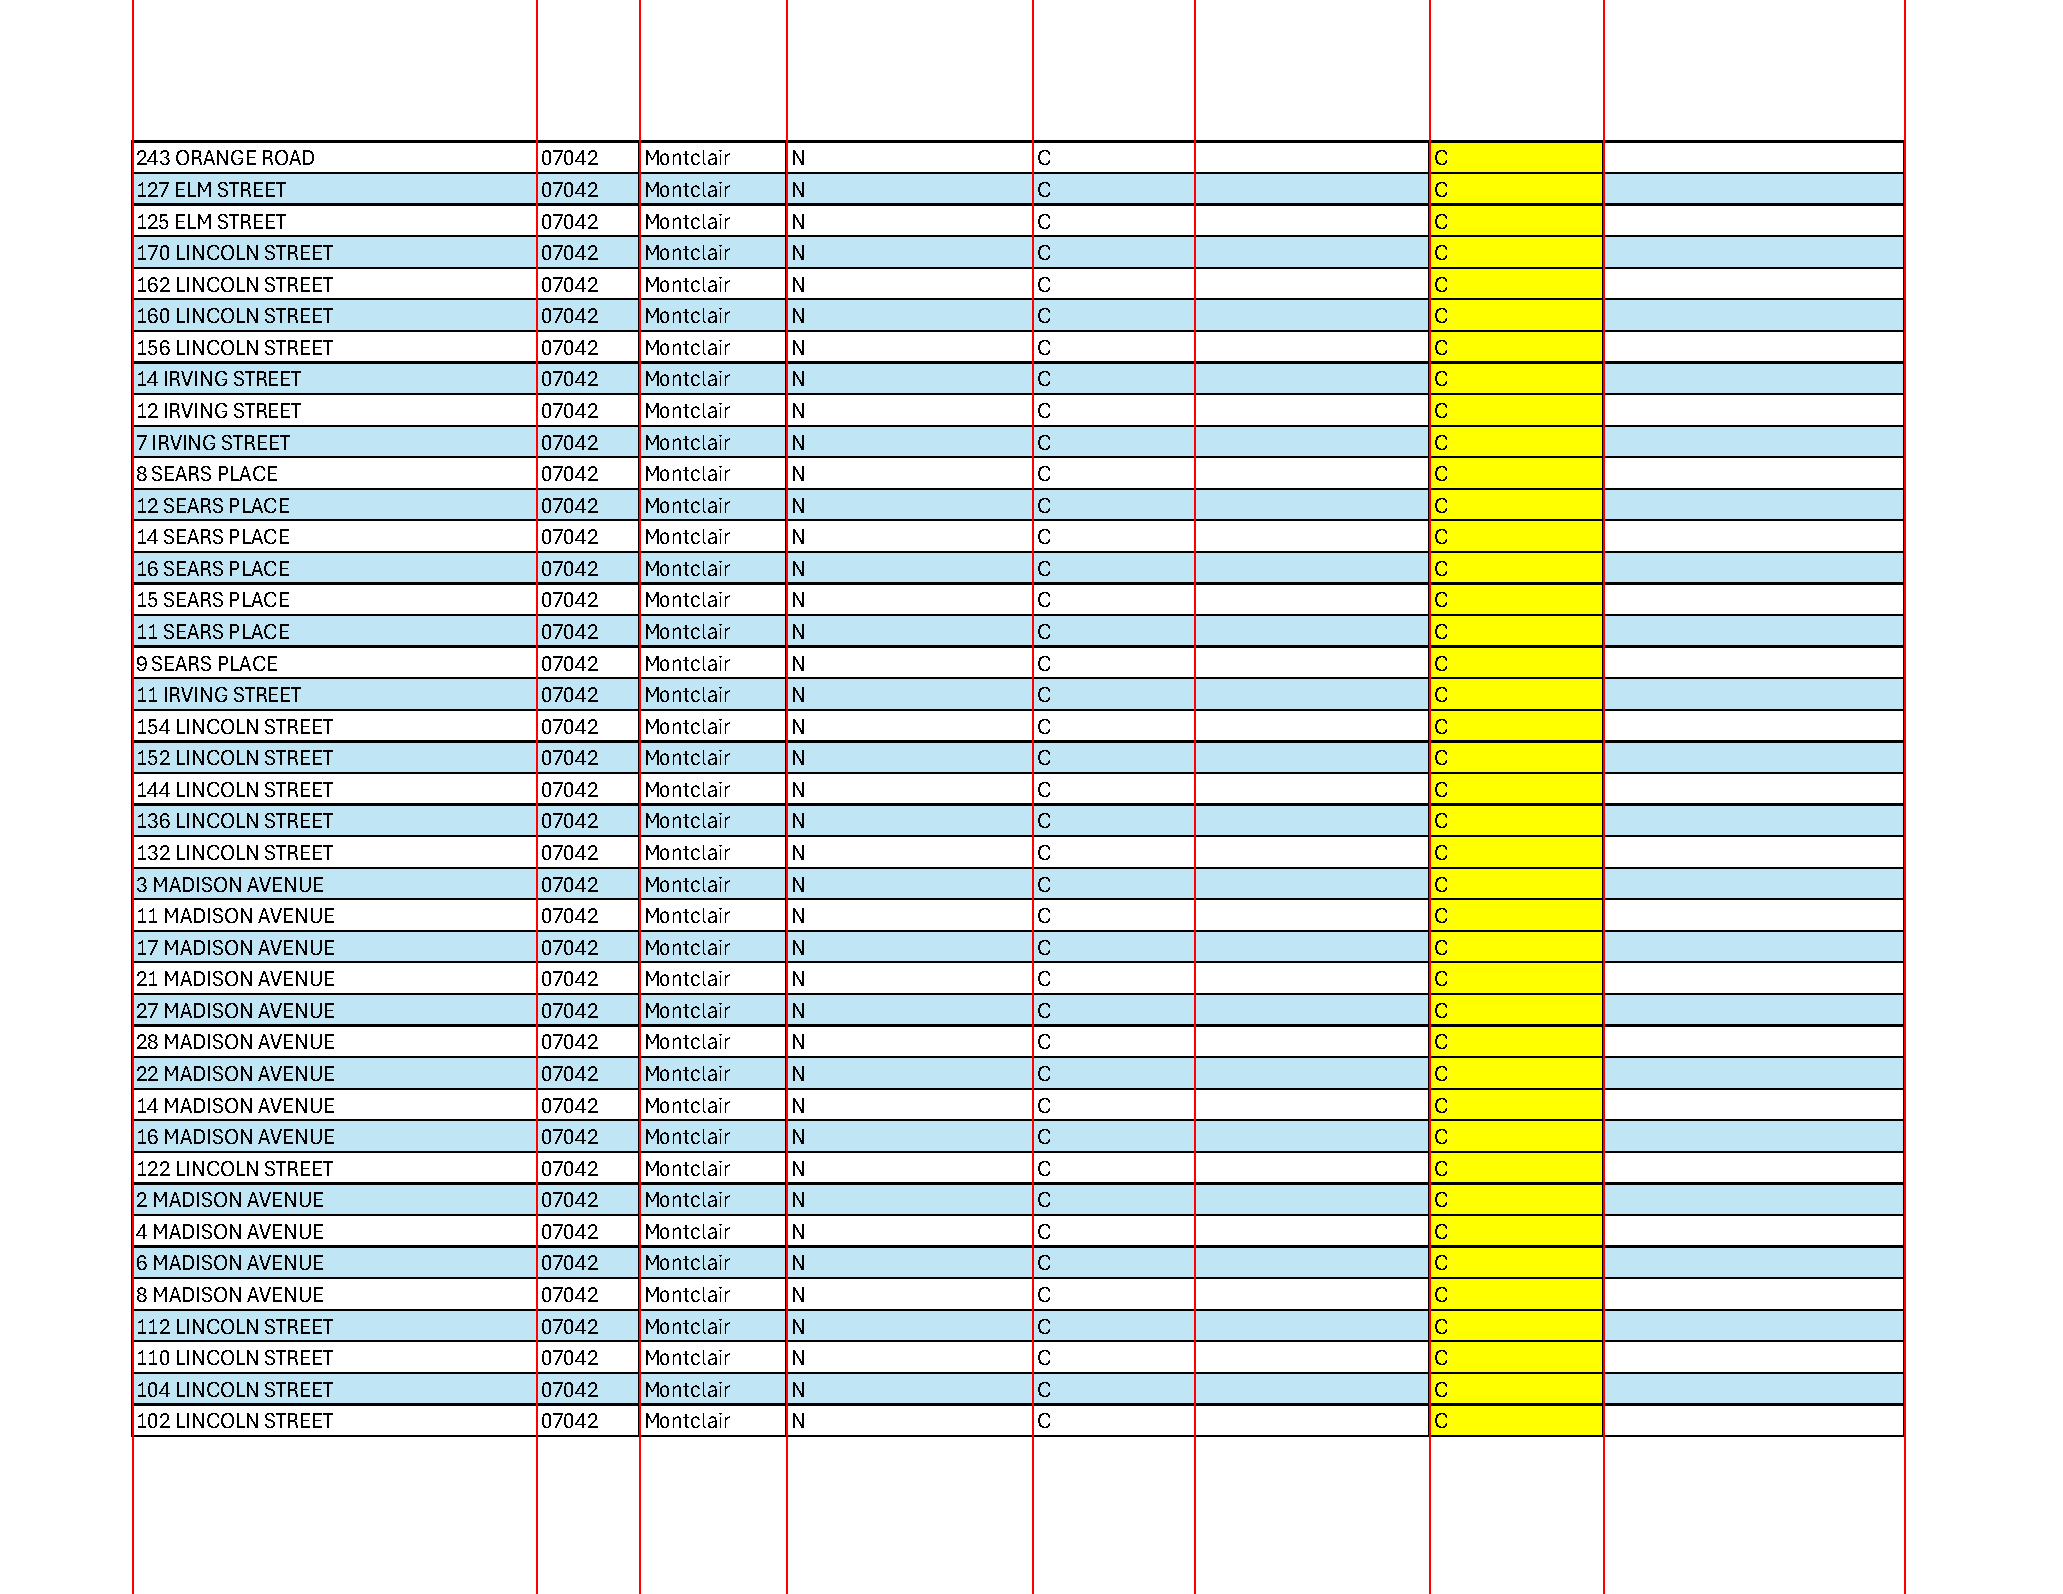

In [4]:
CHECK_PAGE = 252  # 0-indexed; a page that needed the fallback strategy

try:
    with pp.open(PDF_PATH) as pdf:
        im = pdf.pages[CHECK_PAGE].to_image(resolution=150)
        for x in VERTICAL_LINES:
            im.draw_vline(x, stroke="#ff0000", stroke_width=2)
    display(im)
except Exception as e:
    print(f"visual check skipped: {type(e).__name__}: {e}")

## Extract every page

In [5]:
rows_all, diagnostics = [], []

with pp.open(PDF_PATH) as pdf:
    for pn, page in enumerate(pdf.pages):
        rows, strategy = extract_page_rows(page, VERTICAL_LINES)
        rows_all += rows
        diagnostics.append({"page": pn, "n_rows": len(rows), "strategy": strategy})

diag = pl.DataFrame(diagnostics)

print("rows extracted:", len(rows_all))
print()
print(diag.group_by("strategy").len().sort("len", descending=True))

fallback_pages = diag.filter(pl.col("strategy") == "explicit_vlines")["page"].to_list()
empty_pages = diag.filter(pl.col("n_rows") == 0)["page"].to_list()
print()
print(f"pages needing fallback : {fallback_pages}")
print(f"pages yielding 0 rows  : {empty_pages}")

rows extracted: 10845

shape: (3, 2)
┌─────────────────┬─────┐
│ strategy        ┆ len │
│ ---             ┆ --- │
│ str             ┆ u32 │
╞═════════════════╪═════╡
│ default         ┆ 252 │
│ explicit_vlines ┆ 13  │
│ none            ┆ 1   │
└─────────────────┴─────┘

pages needing fallback : [252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264]
pages yielding 0 rows  : [265]


## Assemble and QA

In [6]:
df_addr = pl.DataFrame(rows_all, schema=TBL_COLS, orient="row")
df_addr_unique = (
    df_addr
    .filter(pl.col("address") != "")
    .unique()
    .sort("address")
)

print(f"raw rows          : {df_addr.height}")
print(f"unique, non-empty : {df_addr_unique.height}")
df_addr_unique.head()

raw rows          : 10845
unique, non-empty : 10593


address,zip,town,suspected_lead,psl_materials,psl_other,service_line,csl_other
str,str,str,str,str,str,str,str
"""1 ALEXANDER AVENUE""","""07043""","""Montclair""","""N""","""C""","""""","""C""",""""""
"""1 ALEXANDER COURT""","""07043""","""Montclair""","""N""","""C""","""""","""C""",""""""
"""1 AMHERST PLACE""","""07043""","""Montclair""","""N""","""C""","""""","""C""",""""""
"""1 Argyle Road""","""07043""","""Montclair""","""Y""","""C""","""""","""G""",""""""
"""1 BERKELEY PLACE""","""07042""","""Montclair""","""N""","""C""","""""","""C""",""""""


In [7]:
# --- QA -------------------------------------------------------------------
checks = {
    "header rows leaked":
        df_addr_unique.filter(
            pl.col("address").str.to_lowercase().str.contains("street address")
        ).height,
    "blank zip (02 recovers these from the address)":
        df_addr_unique.filter(pl.col("zip") == "").height,
    "zip not 5 digits":
        df_addr_unique.filter(~pl.col("zip").str.contains(r"^\d{5}$")).height,
    "address with no leading number (04 drops these)":
        df_addr_unique.filter(~pl.col("address").str.contains(r"^\d")).height,
    "towns other than Montclair":
        df_addr_unique.filter(pl.col("town").str.to_lowercase() != "montclair").height,
}
for k, v in checks.items():
    print(f"{v:>6}  {k}")

assert checks["header rows leaked"] == 0, "header rows leaked into the output"

print()
for col in ["suspected_lead", "psl_materials", "service_line"]:
    print(df_addr_unique[col].value_counts().sort("count", descending=True))

     0  header rows leaked
    13  blank zip (02 recovers these from the address)
    14  zip not 5 digits
    56  address with no leading number (04 drops these)
     0  towns other than Montclair

shape: (2, 2)
┌────────────────┬───────┐
│ suspected_lead ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ N              ┆ 9766  │
│ Y              ┆ 827   │
└────────────────┴───────┘
shape: (5, 2)
┌───────────────┬───────┐
│ psl_materials ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ C             ┆ 10558 │
│ G             ┆ 13    │
│ UX            ┆ 13    │
│ L             ┆ 5     │
│ O             ┆ 4     │
└───────────────┴───────┘
shape: (6, 2)
┌──────────────┬───────┐
│ service_line ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ C            ┆ 9756  │
│ UX           ┆ 378   │
│ G            ┆ 220   │
│ L            ┆ 128   │
│ O            ┆ 110   │
│ NA   

In [8]:
# --- what "O" means -------------------------------------------------------
# 05-ward-analysis.R currently has:  . == "O" ~ "O",  # we don't know what "O" means
# The 8th column answers it. These are the customer-side materials recorded as
# "Other", which matters because brass qualifies for the replacement program
# while iron, PVC and poly do not.
(
    df_addr_unique
    .filter(pl.col("csl_other") != "")
    .with_columns(pl.col("csl_other").str.to_uppercase().str.strip_chars().alias("csl_other_norm"))
    ["csl_other_norm"].value_counts().sort("count", descending=True)
)

csl_other_norm,count
str,u32
"""BRASS""",76
"""IRON""",21
"""PVC""",5
"""POLY""",4
"""CAST IRON""",1
"""TOWN SIDE REPLACED 9-5-24""",1
"""BRASS FOUND""",1
"""YELLOW BRASS""",1
"""I""",1


## Export

In [9]:
# Write empty cells as true nulls, not as quoted "". readr's is.na() drives the
# zip-recovery branch in 02-data-cleaning.R, so blank fields must arrive as NA.
df_out = df_addr_unique.with_columns([
    pl.when(pl.col(c).str.strip_chars() == "")
      .then(None)
      .otherwise(pl.col(c))
      .alias(c)
    for c in TBL_COLS
])

df_out.write_csv(OUT_PATH)
print(f"wrote {df_out.height} rows x {df_out.width} cols to {OUT_PATH}")
print()
print("null counts per column:")
print(df_out.null_count())

wrote 10593 rows x 8 cols to data_intermediate\lead_service_line_addresses.csv

null counts per column:
shape: (1, 8)
┌─────────┬─────┬──────┬────────────────┬───────────────┬───────────┬──────────────┬───────────┐
│ address ┆ zip ┆ town ┆ suspected_lead ┆ psl_materials ┆ psl_other ┆ service_line ┆ csl_other │
│ ---     ┆ --- ┆ ---  ┆ ---            ┆ ---           ┆ ---       ┆ ---          ┆ ---       │
│ u32     ┆ u32 ┆ u32  ┆ u32            ┆ u32           ┆ u32       ┆ u32          ┆ u32       │
╞═════════╪═════╪══════╪════════════════╪═══════════════╪═══════════╪══════════════╪═══════════╡
│ 0       ┆ 13  ┆ 0    ┆ 0              ┆ 0             ┆ 10589     ┆ 0            ┆ 10482     │
└─────────┴─────┴──────┴────────────────┴───────────────┴───────────┴──────────────┴───────────┘
